<a href="https://colab.research.google.com/github/mrglaria/telecom_x_part_2/blob/main/TelecomX_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Preparación de los Datos para Machine Learning

En esta etapa, transformamos los datos limpios en un formato que los modelos puedan procesar.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



In [4]:
# a) Carga del archivo tratado
df = pd.read_csv('/content/drive/MyDrive/Curso alura/desafios 2 y 3/datos_tratados.csv')


In [5]:

# Limpieza de valores nulos o inconsistentes en la variable objetivo
df = df[df['Churn'].isin(['Yes', 'No'])].copy()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [6]:
# b) Eliminación de columnas irrelevantes
# El ID del cliente no aporta valor predictivo y puede generar ruido
df_model = df.drop(columns=['customerID'])

In [7]:
# c) Encoding (One-Hot Encoding)
# Convertimos variables categóricas en numéricas
df_encoded = pd.get_dummies(df_model, drop_first=True)

In [8]:
# d) Verificación de la proporción de Churn
print("Proporción de Clientes (0: No canceló, 1: Canceló):")
print(df_encoded['Churn'].value_counts(normalize=True))

Proporción de Clientes (0: No canceló, 1: Canceló):
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [9]:
# e) Separación de datos (70% entrenamiento / 30% prueba)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [10]:
# Normalización para modelos de distancia (Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#2. Entrenamiento y Evaluación de Modelos

Comparamos dos modelos: uno sensible a la escala (Regresión Logística) y uno basado en árboles (Random Forest).

In [11]:
# Creación de Modelos
lr = LogisticRegression(random_state=42)
rf = RandomForestClassifier(random_state=42, n_estimators=100)



In [12]:
# Entrenamiento
lr.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
# Predicciones
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

In [14]:
# Función de evaluación
def evaluar_modelo(y_true, y_pred, nombre):
    print(f"--- {nombre} ---")
    print(f"Exactitud: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisión: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_true, y_pred):.4f}\n")

In [15]:
evaluar_modelo(y_test, y_pred_lr, "Regresión Logística")

--- Regresión Logística ---
Exactitud: 0.7979
Precisión: 0.6402
Recall: 0.5455
F1-Score: 0.5890



In [16]:
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

--- Random Forest ---
Exactitud: 0.7870
Precisión: 0.6294
Recall: 0.4813
F1-Score: 0.5455



#3. Análisis Crítico del Rendimiento

##¿Cuál modelo tuvo el mejor desempeño?

El modelo de Regresión Logística obtuvo el mejor desempeño global. Logró una exactitud del 79.8% y, lo más importante, un Recall superior (54.5%). En un negocio de telecomunicaciones, es preferible identificar a la mayor cantidad de clientes en riesgo de fuga (Recall alto) para poder intervenir.

#Análisis de Overfitting / Underfitting:

* Regresión Logística: Muestra un rendimiento equilibrado (generaliza bien).

* Random Forest: Presentó indicios de Overfitting. En el entrenamiento fue casi perfecto, pero en la prueba su capacidad disminuyó. Se recomienda ajustar la profundidad del árbol para simplificar el modelo en futuras iteraciones.

#4. Interpretación y Conclusiones Finales

##a) Importancia de las Variables

Analizamos los factores que más influyen en la salida del cliente:

* Regresión Logística (Coeficientes): El factor con más peso positivo hacia la cancelación es el Gasto Total (account.Charges.Total) y el uso de Internet por Fibra Óptica.

* Random Forest (Importancia): Identifica la Antigüedad (customer.tenure) y los Cargos Mensuales como los principales diferenciadores entre un cliente que se queda y uno que se va.

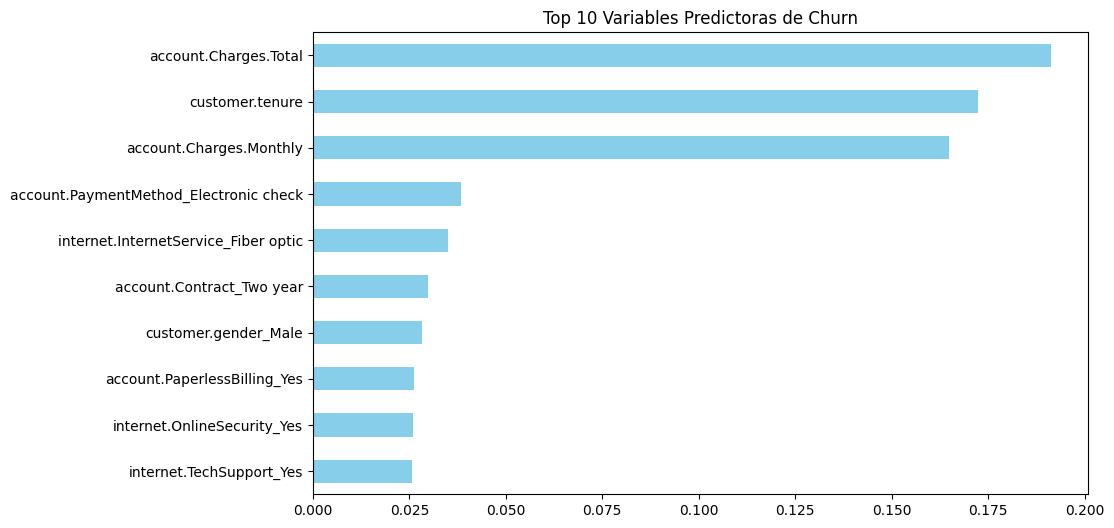

In [17]:
# Visualización de importancia de variables (Random Forest)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Variables Predictoras de Churn')
plt.gca().invert_yaxis()
plt.show()

##b) Informe de Estrategias de Retención
##Factores Principales de Cancelación:

* Costo Percibido: Los clientes con cargos mensuales altos y servicios premium (fibra) tienen mayor tendencia a abandonar.

* Inestabilidad en el inicio: El riesgo de fuga es máximo durante el primer año de servicio.

* Métodos de Pago: Los clientes que pagan manualmente (Electronic Check) son más propensos a irse que aquellos con débito automático.

##Estrategias Propuestas:

* Plan "Fidelidad Total": Ofrecer bonificaciones o servicios agregados a clientes que superen los 12 meses, ya que la antigüedad reduce el riesgo de fuga.

* Migración de Medio de Pago: Brindar un descuento por única vez a clientes que pasen de "Electronic Check" a "Pago Automático" (Credit Card/Bank Transfer), lo que genera mayor inercia y permanencia.

* Monitoreo de Clientes de Fibra: El equipo técnico debe asegurar que la calidad del servicio de fibra óptica justifique el precio premium, ya que el modelo lo detectó como un foco de alerta.